# Laboratorio 1
**Construya un programa en python que permita encontrar los mejores valores de b y w de la ecuación de la línea recta: y = b + wx, a partir de un dataset que usted seleccione, no se debe utilizar ningún framework o ecuaciones de regresiones, solo debe realizar un programa simple, con estructuras de control decisivo y repetitivo. Una vez que identifique los mejores valores de b y w, realice inferencias para 10 nuevos valores de x, explique los resultados obtenidos y el algoritmo empleado.**

# Dataset Seleccionado
Student Study Hours dataset.<br>
Este dataset representa la relación entre las horas que un estudiante dedica a estudiar y la calificación (score) que obtiene.
La idea es ver si existe una tendencia lineal: a más horas de estudio, ¿mejor es la calificación obtenida?<br>
Donde x = Hours, variable independiente (lo que ya conocemos).<br>
y = Scores, variable dependiente (lo que queremos predecir a partir de x).

In [1]:
# Conectando / vinculando nuestro drive con la sesión de Google Colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Cargar Dataset

In [2]:
# Cargar el dataset desde Google Drive
ruta = '/content/drive/MyDrive/machine learning/datasets/student_scores.csv'

with open(ruta, 'r') as f:
    contenido = f.readlines()

print("Total de registros (incluye encabezado):", len(contenido))
print("Encabezado:", contenido[0].strip())
print("Vista previa:")
for fila in contenido[1:6]:
    print(fila.strip())

Total de registros (incluye encabezado): 36
Encabezado: Hours,Scores
Vista previa:
2.5,21
5.1,47
3.2,27
8.5,75
3.5,30


**Separando el texto en dos listas numéricas: horas de estudio y calificaciones.**

In [3]:
horas = []
notas = []

indice = 0
for fila in contenido:
    if indice == 0:              # estructura DECISIVA: saltar el encabezado
        indice += 1
        continue
    fila = fila.strip()
    if fila == "":                # estructura DECISIVA: ignorar líneas vacías
        continue
    valores = fila.split(",")
    horas.append(float(valores[0]))
    notas.append(float(valores[1]))
    indice += 1

n = len(horas)
print("Cantidad de estudiantes:", n)
print("Horas (primeros 5):", horas[:5])
print("Notas (primeros 5):", notas[:5])

Cantidad de estudiantes: 35
Horas (primeros 5): [2.5, 5.1, 3.2, 8.5, 3.5]
Notas (primeros 5): [21.0, 47.0, 27.0, 75.0, 30.0]


# Búsqueda de b y w (descenso por gradiente)

In [5]:
# Modelo:   nota_estimada = b + w * horas
# Costo:    J = (1/n) * suma( (b + w*horas_i - nota_i)^2 )
# Gradiente respecto a b: (2/n) * suma(error_i)
# Gradiente respecto a w: (2/n) * suma(error_i * horas_i)

b = 0.0
w = 0.0
alpha = 0.01              # tasa de aprendizaje
costo_anterior = float('inf')
historial_costo = []      # guardamos el costo de cada iteración para graficar después

max_iteraciones = 20000
iteracion = 0

while iteracion < max_iteraciones:        # estructura REPETITIVA (while, en vez de for)
    suma_error = 0.0
    suma_error_x = 0.0
    suma_costo = 0.0

    for i in range(n):                    # estructura REPETITIVA: recorre cada estudiante
        prediccion = b + w * horas[i]
        error = prediccion - notas[i]
        suma_error += error
        suma_error_x += error * horas[i]
        suma_costo += error ** 2

    costo = suma_costo / n
    b = b - alpha * (2 / n) * suma_error
    w = w - alpha * (2 / n) * suma_error_x
    historial_costo.append(costo)

    if abs(costo_anterior - costo) < 1e-7:     # estructura DECISIVA: ¿ya convergió?
        print(f"El algoritmo convergió en la iteración {iteracion}")
        break

    costo_anterior = costo
    iteracion += 1

print(f"\nMejor b (intercepto): {round(b, 4)}")
print(f"Mejor w (pendiente):   {round(w, 4)}")
print(f"Costo final:           {round(costo, 4)}")

El algoritmo convergió en la iteración 1405

Mejor b (intercepto): 3.2573
Mejor w (pendiente):   9.6569
Costo final:           34.1135


# Inferencia con 10 nuevos valores de x

In [7]:
horas_nuevas = [0.5, 1.8, 2.7, 3.9, 4.6, 5.8, 6.4, 7.5, 8.9, 9.5]

print("Predicciones de calificación según horas de estudio:\n")
i = 0
while i < len(horas_nuevas):               # estructura REPETITIVA (while)
    h = horas_nuevas[i]
    nota_estimada = b + w * h
    if nota_estimada > 100:                # estructura DECISIVA: la nota no puede pasar de 100
        nota_estimada = 100.0
    print(f"Horas de estudio = {h:4.1f} -> calificación estimada = {nota_estimada:.2f}")
    i += 1

Predicciones de calificación según horas de estudio:

Horas de estudio =  0.5 -> calificación estimada = 8.09
Horas de estudio =  1.8 -> calificación estimada = 20.64
Horas de estudio =  2.7 -> calificación estimada = 29.33
Horas de estudio =  3.9 -> calificación estimada = 40.92
Horas de estudio =  4.6 -> calificación estimada = 47.68
Horas de estudio =  5.8 -> calificación estimada = 59.27
Horas de estudio =  6.4 -> calificación estimada = 65.06
Horas de estudio =  7.5 -> calificación estimada = 75.68
Horas de estudio =  8.9 -> calificación estimada = 89.20
Horas de estudio =  9.5 -> calificación estimada = 95.00


# Gráficas de resultados

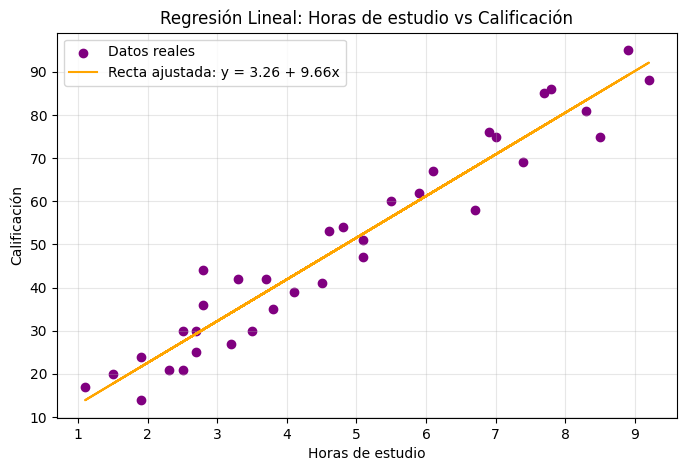

In [8]:
import matplotlib.pyplot as plt

notas_predichas = [b + w * h for h in horas]

plt.figure(figsize=(8,5))
plt.scatter(horas, notas, color='purple', label='Datos reales')
plt.plot(horas, notas_predichas, color='orange', label=f'Recta ajustada: y = {b:.2f} + {w:.2f}x')
plt.xlabel('Horas de estudio')
plt.ylabel('Calificación')
plt.title('Regresión Lineal: Horas de estudio vs Calificación')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

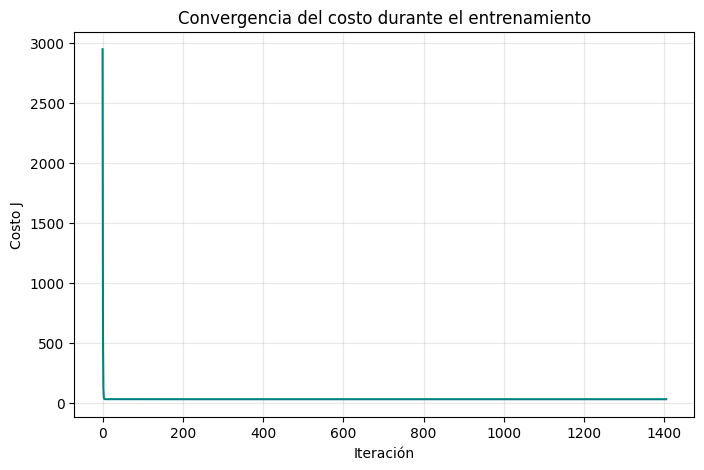

In [9]:
plt.figure(figsize=(8,5))
plt.plot(historial_costo, color='teal')
plt.xlabel('Iteración')
plt.ylabel('Costo J')
plt.title('Convergencia del costo durante el entrenamiento')
plt.grid(True, alpha=0.3)
plt.show()

# Explicación de resultados y algoritmo empleado

**Algoritmo empleado:** Descenso por gradiente (batch gradient descent). El programa parte de b=0 y w=0 (una recta sin información) y en cada iteración recorre las 35 filas del dataset para calcular el error de predicción y el gradiente de la función de costo respecto a b y w. Luego actualiza ambos parámetros moviéndolos en la dirección contraria al gradiente (la dirección que reduce el error), un paso proporcional a la tasa de aprendizaje (alpha=0.01). Este proceso se repite hasta que el costo deja de disminuir de forma significativa entre una iteración y la siguiente (convergencia).

**Interpretación de b y w:**
- **b** representa la calificación base teórica que el modelo predice para un estudiante con 0 horas de estudio.
- **w** representa cuánto sube la calificación, en promedio, por cada hora adicional de estudio.

**Interpretación de las inferencias:** Las predicciones sobre los 10 nuevos valores de horas de estudio muestran una relación creciente y consistente: a más horas dedicadas a estudiar, mayor es la calificación estimada por el modelo, siguiendo la fórmula aprendida nota = b + w·horas. Estos 10 valores no fueron parte del entrenamiento, por lo que representan el uso real del modelo ya entrenado sobre datos nuevos (inferencia).

**Sobre el ajuste del modelo:** La gráfica de dispersión muestra que los puntos reales siguen de cerca la recta ajustada, lo que indica una fuerte relación lineal entre horas de estudio y calificación en este dataset. La gráfica de convergencia del costo confirma que el algoritmo fue reduciendo el error de forma consistente hasta estabilizarse, señal de que encontró un buen mínimo para b y w.